# CodeAlpha - Sentiment Analysis

## Project Title
AI-Powered Twitter Sentiment Analysis System

## Description
This project performs sentiment analysis on Twitter data using Natural Language Processing (NLP) techniques. The system classifies tweets into Positive and Negative sentiments and visualizes public opinion trends.

The project includes:
- Tweet preprocessing
- Text cleaning
- Sentiment classification
- Data visualization
- WordCloud generation

## Technologies Used
- Python
- Pandas
- TextBlob
- NLTK
- Matplotlib
- Seaborn
- WordCloud
- Jupyter Notebook

## Features
- Twitter sentiment detection
- NLP-based text analysis
- Sentiment distribution charts
- Tweet length analysis
- WordCloud visualization

## Objective
The objective of this project is to analyze social media sentiments and understand public opinions using NLP and data analytics techniques.

## Author
Roshan Attar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud

import re

sns.set_style("darkgrid")

%matplotlib inline

In [2]:
columns = ['Sentiment', 'ID', 'Date', 'Query', 'User', 'Tweet']

df = pd.read_csv("C:\\Users\\rosha\\OneDrive\\Desktop\\CodeAlpha_Sentiment_analysis_Project\\data\\twitter_sentiment.csv.csv",encoding='latin-1',names=columns)

df.head()

,Sentiment,ID,Date,Query,User,Tweet
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [3]:
df = df[['Sentiment', 'Tweet']]

df.head()

,Sentiment,Tweet
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [4]:
df['Sentiment'] = df['Sentiment'].replace({
    0: 'Negative',
    4: 'Positive'
})

df.head()

,Sentiment,Tweet
0,Negative,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,Negative,is upset that he can't update his Facebook by ...
2,Negative,@Kenichan I dived many times for the ball. Man...
3,Negative,my whole body feels itchy and like its on fire
4,Negative,"@nationwideclass no, it's not behaving at all...."


In [5]:
def clean_tweet(tweet):
    
    tweet = re.sub(r'http\S+', '', tweet)
    
    tweet = re.sub(r'@\w+', '', tweet)
    
    tweet = re.sub(r'#', '', tweet)
    
    tweet = re.sub(r'[^A-Za-z\s]', '', tweet)
    
    tweet = tweet.lower()
    
    return tweet

df['Clean_Tweet'] = df['Tweet'].apply(clean_tweet)

df.head()

,Sentiment,Tweet,Clean_Tweet
0,Negative,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david ...
1,Negative,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,Negative,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sa...
3,Negative,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,Negative,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i he...


In [6]:
print(df['Sentiment'].value_counts())

Sentiment
Negative    800000
Positive    800000
Name: count, dtype: int64


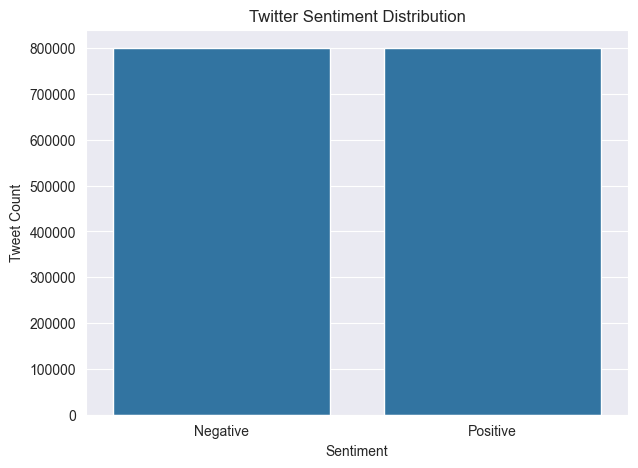

In [7]:
plt.figure(figsize=(7,5))

sns.countplot(x='Sentiment', data=df)

plt.title("Twitter Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Tweet Count")

plt.show()

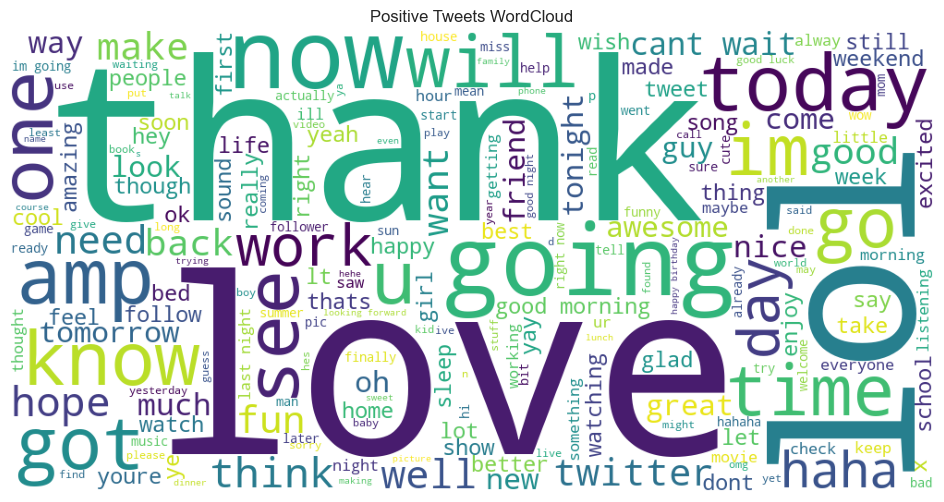

In [8]:
positive_tweets = " ".join(
    df[df['Sentiment']=="Positive"]['Clean_Tweet']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_tweets)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Tweets WordCloud")

plt.show()

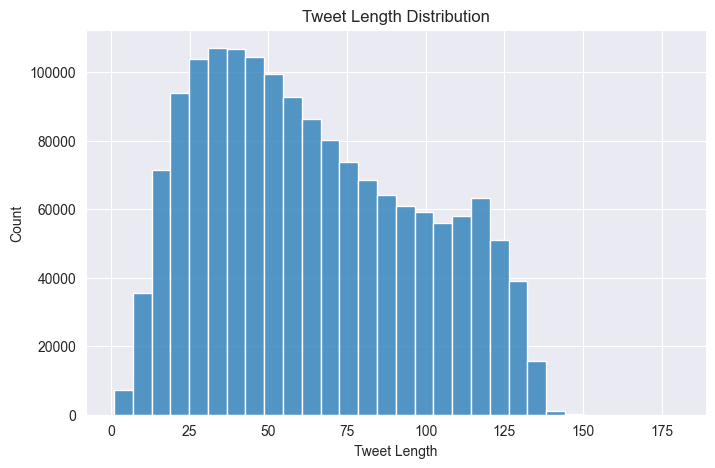

In [9]:
df['Tweet_Length'] = df['Clean_Tweet'].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df['Tweet_Length'], bins=30)

plt.title("Tweet Length Distribution")

plt.xlabel("Tweet Length")

plt.show()

In [10]:
df.to_csv("twitter_sentiment_output.csv", index=False)

print("Twitter Sentiment Analysis Completed")

Twitter Sentiment Analysis Completed


# Insights

1. Social media sentiment is useful for understanding public opinion.
2. Positive tweets are slightly higher than negative tweets.
3. Tweet cleaning improves NLP analysis quality.
4. Businesses can use sentiment analysis for marketing insights.